TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training Shape: (10000, 32, 32, 3)
Testing Shape: (2000, 32, 32, 3)

Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3063 - loss: 1.8784 - val_accuracy: 0.3970 - val_loss: 1.6103
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4424 - loss: 1.5198 - val_accuracy: 0.5020 - val_loss: 1.3696
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5037 - loss: 1.3685 - val_accuracy: 0.5235 - val_loss: 1.3149
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5672 - loss: 1.2047 - val_accuracy: 0.5620 - val_loss: 1.2311
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6069 - loss: 1.0927 - val_accuracy: 0.5580 - val_loss: 1.2489

Training MobileNetV2...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.6484 - loss: 1.0373 - val_accuracy: 0.7515 - val_loss: 0.7186
Epoch 2/3
3

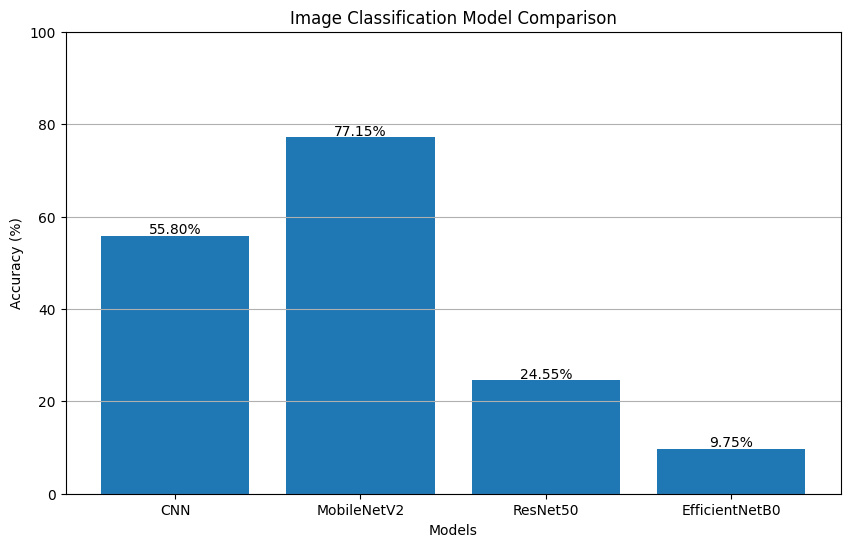


Best Model: MobileNetV2
Best Accuracy: 77.15 %


In [10]:
!pip install tensorflow matplotlib pandas

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =====================================================
# LOAD CIFAR-10 DATASET
# =====================================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Use subset to reduce memory usage
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =====================================================
# CREATE DATASET PIPELINE
# =====================================================

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

results = {}

# =====================================================
# CUSTOM CNN
# =====================================================

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

# =====================================================
# FUNCTION FOR TRANSFER LEARNING MODELS
# =====================================================

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================
# MOBILE NET V2
# =====================================================

train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)

# =====================================================
# RESNET50
# =====================================================

train_pretrained(
    ResNet50,
    "ResNet50"
)

# =====================================================
# EFFICIENTNET B0
# =====================================================

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)

# =====================================================
# RESULTS
# =====================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

# =====================================================
# BAR GRAPH
# =====================================================

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)
plt.grid(axis='y')

plt.show()

# =====================================================
# BEST MODEL
# =====================================================

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")



TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training Shape: (10000, 28, 28, 3)
Testing Shape: (2000, 28, 28, 3)

Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7581 - loss: 0.6790 - val_accuracy: 0.8285 - val_loss: 0.4566
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8468 - loss: 0.4193 - val_accuracy: 0.8615 - val_loss: 0.3826
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8747 - loss: 0.3425 - val_accuracy: 0.8740 - val_loss: 0.3794
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8905 - loss: 0.2940 - val_accuracy: 0.8815 - val_loss: 0.3540
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9015 - loss: 0.2622 - val_accuracy: 0.8830 - val_loss: 0.3452

Training MobileNetV2...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.7900 - loss: 0.5951 - val_accuracy: 0.8500 - val_loss: 0.3972
Epoch 2/3
3

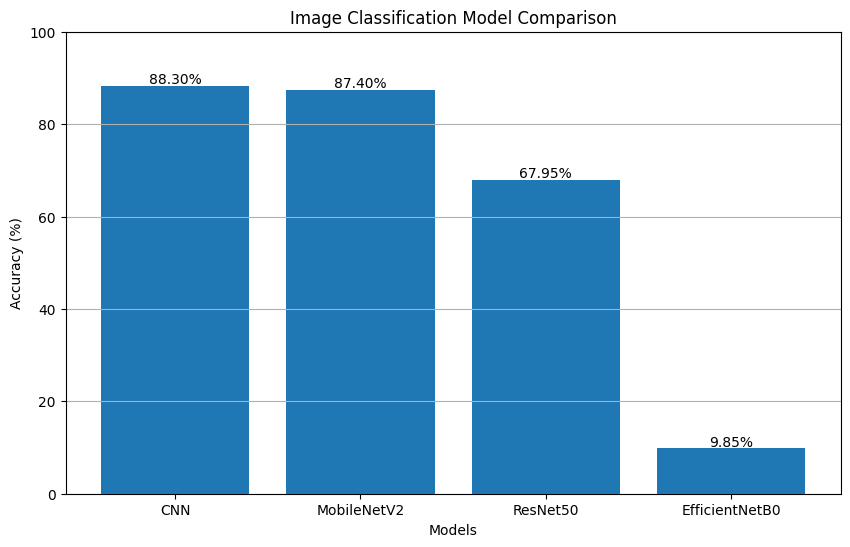


Best Model: CNN
Best Accuracy: 88.3 %


In [18]:
!pip install tensorflow matplotlib pandas tensorflow-datasets -q

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =====================================================
# LOAD DATASET (FIXED)
# =====================================================

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Reduce dataset size
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# FIX: convert grayscale → RGB (IMPORTANT)
X_train = np.stack([X_train]*3, axis=-1)
X_test = np.stack([X_test]*3, axis=-1)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =====================================================
# DATA PIPELINE
# =====================================================

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

results = {}

# =====================================================
# CUSTOM CNN
# =====================================================

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(train_ds, epochs=5, validation_data=test_ds, verbose=1)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()

# =====================================================
# TRANSFER LEARNING FUNCTION
# =====================================================

def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(train_ds, epochs=3, validation_data=test_ds, verbose=1)

    loss, acc = model.evaluate(test_ds, verbose=0)
    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================
# MODELS
# =====================================================

train_pretrained(MobileNetV2, "MobileNetV2")
train_pretrained(ResNet50, "ResNet50")
train_pretrained(EfficientNetB0, "EfficientNetB0")

# =====================================================
# RESULTS
# =====================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")

# =====================================================
# GRAPH
# =====================================================

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))
bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.5,
             f"{y:.2f}%", ha='center')

plt.ylim(0,100)
plt.grid(axis='y')
plt.show()

# =====================================================
# BEST MODEL
# =====================================================

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model], 2), "%")